# Step 10 & 11: Performance Monitoring & Drift Detection
## Operationalizing ML: When is the Model Degrading?

In production, models degrade due to two fundamentally different phenomena:
1. **Data Drift**: $P(X)$ changes. Input feature distributions shift (e.g., changes in rider request volume, weather, special events).
2. **Concept Drift / Performance Degradation**: $P(Y|X)$ changes. The underlying relationship between input features and demand shifts, causing model accuracy to degrade.

> **CRITICAL RULE**: Detecting data drift does **NOT** automatically mean concept drift has occurred. A model may be robust to data drift. Therefore, we monitor both feature stability (PSI, KS-test) and actual operational performance (Rolling MAE, RMSE, and Bias).


In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

sys.path.append(str(Path.cwd().parent))
from src.drift import calculate_psi, calculate_ks_test, compute_rolling_metrics, detect_sustained_degradation
from src.features import build_feature_pipeline
from src.data_loader import load_processed_demand, split_chronological
from src.config import STREAM_PREDICTIONS_PARQUET, DRIFT_PSI_THRESHOLD

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig_size = (12, 5)

print("Loading stream prediction audit log...")
pred_df = pd.read_parquet(STREAM_PREDICTIONS_PARQUET)
print(f"Loaded {len(pred_df):,} audit records.")
pred_df.head()


Loading stream prediction audit log...
Loaded 150,912 audit records.


,prediction_timestamp,zone,prediction_horizon,predicted_demand,actual_demand,error,absolute_error,model_version
0,2025-01-26,1,15min,0.00,0,0.00,0.00,model_v1
1,2025-01-26,2,15min,0.00,0,0.00,0.00,model_v1
2,2025-01-26,3,15min,15.98,16,-0.02,0.02,model_v1
3,2025-01-26,4,15min,49.16,65,-15.84,15.84,model_v1
4,2025-01-26,5,15min,1.40,3,-1.60,1.60,model_v1


### 1. Rolling Performance Tracking (MAE, RMSE, Bias)
We calculate 24-hour rolling metrics (window of 96 intervals) across the streaming timeline.


In [2]:
rolling_summary = compute_rolling_metrics(pred_df, window_size=96)
rolling_summary.head(10)


,prediction_timestamp,mean_abs_error,mean_sq_error,mean_bias,total_actual,rolling_mae,rolling_rmse,rolling_bias
0,2025-01-26 00:00:00,6.033779,93.648024,-1.253015,10759,NaN,NaN,NaN
1,2025-01-26 00:15:00,5.612290,73.770419,-0.748550,9906,NaN,NaN,NaN
2,2025-01-26 00:30:00,5.349962,81.091490,-1.824542,9641,NaN,NaN,NaN
3,2025-01-26 00:45:00,4.818473,54.152756,-1.271145,9098,5.453626,8.698602,-1.274313
4,2025-01-26 01:00:00,5.143053,61.488540,-0.643130,8786,5.391511,8.534064,-1.148076
5,2025-01-26 01:15:00,4.711183,53.587744,-0.098588,7927,5.278123,8.344050,-0.973162
6,2025-01-26 01:30:00,4.783435,64.152808,-0.505267,7553,5.207454,8.297089,-0.906320
7,2025-01-26 01:45:00,4.168779,41.653905,-0.019847,7006,5.077619,8.089698,-0.795510
8,2025-01-26 02:00:00,4.355534,47.068951,-0.217595,6751,4.997388,7.962514,-0.731298
9,2025-01-26 02:15:00,4.344618,64.400859,0.530573,5971,4.932111,7.968786,-0.605111


### 2. Visualize Rolling MAE & Degradation Thresholds
We set an alert control limit at 15% above the baseline validation MAE.


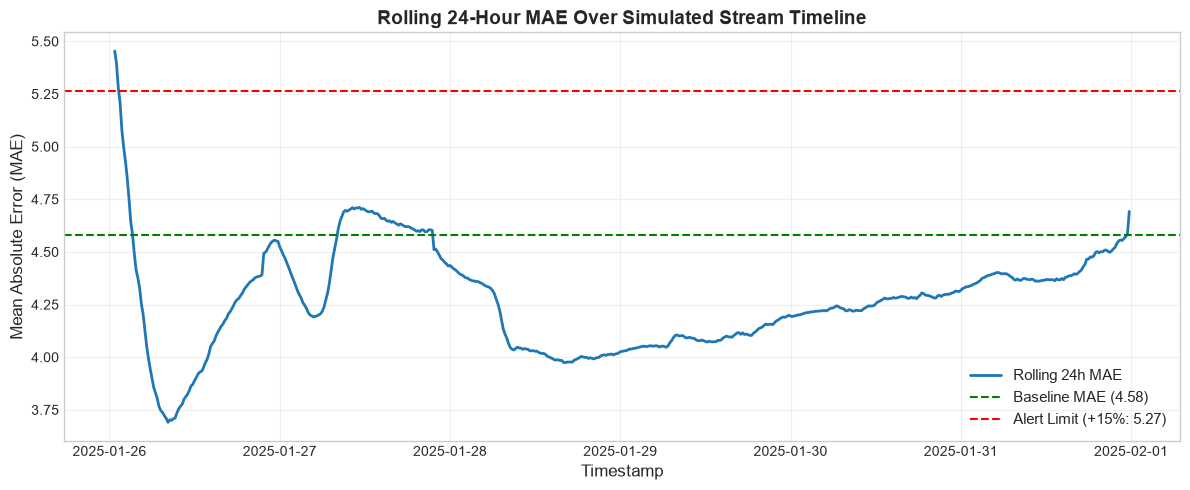

In [3]:
baseline_val_mae = rolling_summary['mean_abs_error'].median()
control_limit = baseline_val_mae * 1.15

plt.figure(figsize=fig_size)
plt.plot(rolling_summary['prediction_timestamp'], rolling_summary['rolling_mae'], 
         color='#1f77b4', lw=2, label='Rolling 24h MAE')
plt.axhline(baseline_val_mae, color='green', linestyle='--', label=f'Baseline MAE ({baseline_val_mae:.2f})')
plt.axhline(control_limit, color='red', linestyle='--', label=f'Alert Limit (+15%: {control_limit:.2f})')

plt.title("Rolling 24-Hour MAE Over Simulated Stream Timeline", fontsize=14, fontweight='bold')
plt.xlabel("Timestamp", fontsize=12)
plt.ylabel("Mean Absolute Error (MAE)", fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### 3. Rolling Bias (Mean Error): Monitoring Systematic Over/Under Prediction
Bias tracks whether the model consistently over-predicts (positive) or under-predicts (negative).


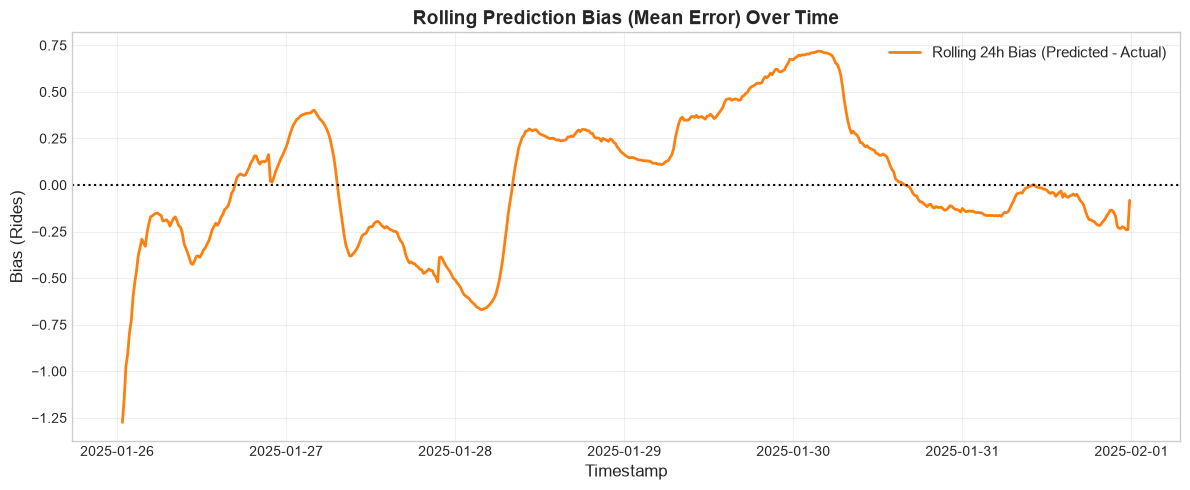

In [4]:
plt.figure(figsize=fig_size)
plt.plot(rolling_summary['prediction_timestamp'], rolling_summary['rolling_bias'], 
         color='#ff7f0e', lw=2, label='Rolling 24h Bias (Predicted - Actual)')
plt.axhline(0, color='black', linestyle=':', lw=1.5)
plt.title("Rolling Prediction Bias (Mean Error) Over Time", fontsize=14, fontweight='bold')
plt.xlabel("Timestamp", fontsize=12)
plt.ylabel("Bias (Rides)", fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### 4. Input Data Drift Detection (PSI & KS-Test)
We compute Population Stability Index (PSI) and Kolmogorov-Smirnov test between the Training reference distribution and the Streaming test window.


In [5]:
grid_df = load_processed_demand()
feat_df = build_feature_pipeline(grid_df, drop_burn_in=True)
train_df, _, test_df = split_chronological(feat_df)

features_to_monitor = ['lag_1', 'lag_4', 'lag_96', 'rolling_mean_4']
drift_results = []

for feat in features_to_monitor:
    ref_vals = train_df[feat].to_numpy()
    cur_vals = test_df[feat].to_numpy()
    
    psi_val = calculate_psi(ref_vals, cur_vals)
    ks_res = calculate_ks_test(ref_vals, cur_vals)
    
    drift_status = "Significant Drift" if psi_val >= 0.25 else ("Moderate Shift" if psi_val >= 0.10 else "Stable")
    
    drift_results.append({
        'Feature': feat,
        'PSI': psi_val,
        'PSI_Status': drift_status,
        'KS_Statistic': ks_res['ks_statistic'],
        'KS_P_Value': ks_res['p_value'],
        'KS_Drift': ks_res['is_drift']
    })

drift_df = pd.DataFrame(drift_results)
print("Data Drift Profiling Summary:")
print(drift_df.to_string(index=False))


Data Drift Profiling Summary:
       Feature    PSI PSI_Status  KS_Statistic  KS_P_Value  KS_Drift
         lag_1 0.0011     Stable        0.0083    0.000001     False
         lag_4 0.0011     Stable        0.0081    0.000002     False
        lag_96 0.0008     Stable        0.0110    0.000000     False
rolling_mean_4 0.0014     Stable        0.0093    0.000000     False


### 5. Sustained Performance Degradation Check
We check whether rolling MAE sustained an increase above the control limit for consecutive periods.


In [6]:
has_degraded, degraded_idx = detect_sustained_degradation(
    rolling_summary['rolling_mae'],
    baseline_mae=baseline_val_mae,
    threshold_pct=0.15,
    consecutive_periods=4
)

print(f"Sustained Performance Degradation Detected: {has_degraded}")
if has_degraded:
    print(f"Triggering Continual Learning / Model Update Workflow at timestamp: "
          f"{rolling_summary.loc[degraded_idx[0], 'prediction_timestamp']}")
else:
    print("Model performance remains within acceptable operational boundaries.")


Sustained Performance Degradation Detected: False
Model performance remains within acceptable operational boundaries.
